In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split
import mlflow
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [3]:
mlflow.set_experiment("Exp 4.4 - Light GBM Hyperparam Tuning")

2025/06/09 21:59:29 INFO mlflow.tracking.fluent: Experiment with name 'Exp 4.4 - Light GBM Hyperparam Tuning' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/556109085172490767', creation_time=1749486569798, experiment_id='556109085172490767', last_update_time=1749486569798, lifecycle_stage='active', name='Exp 4.4 - Light GBM Hyperparam Tuning', tags={}>

In [4]:
from sklearn import set_config
set_config(transform_output="pandas")

In [5]:
data = pd.read_csv('../data/processed/data_processed_v2.csv')

In [6]:
data.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
is_weekend                0
pickup_time_minutes    1640
order_time_of_day      2070
distance               3630
distance_type          3630
time_taken                0
dtype: int64

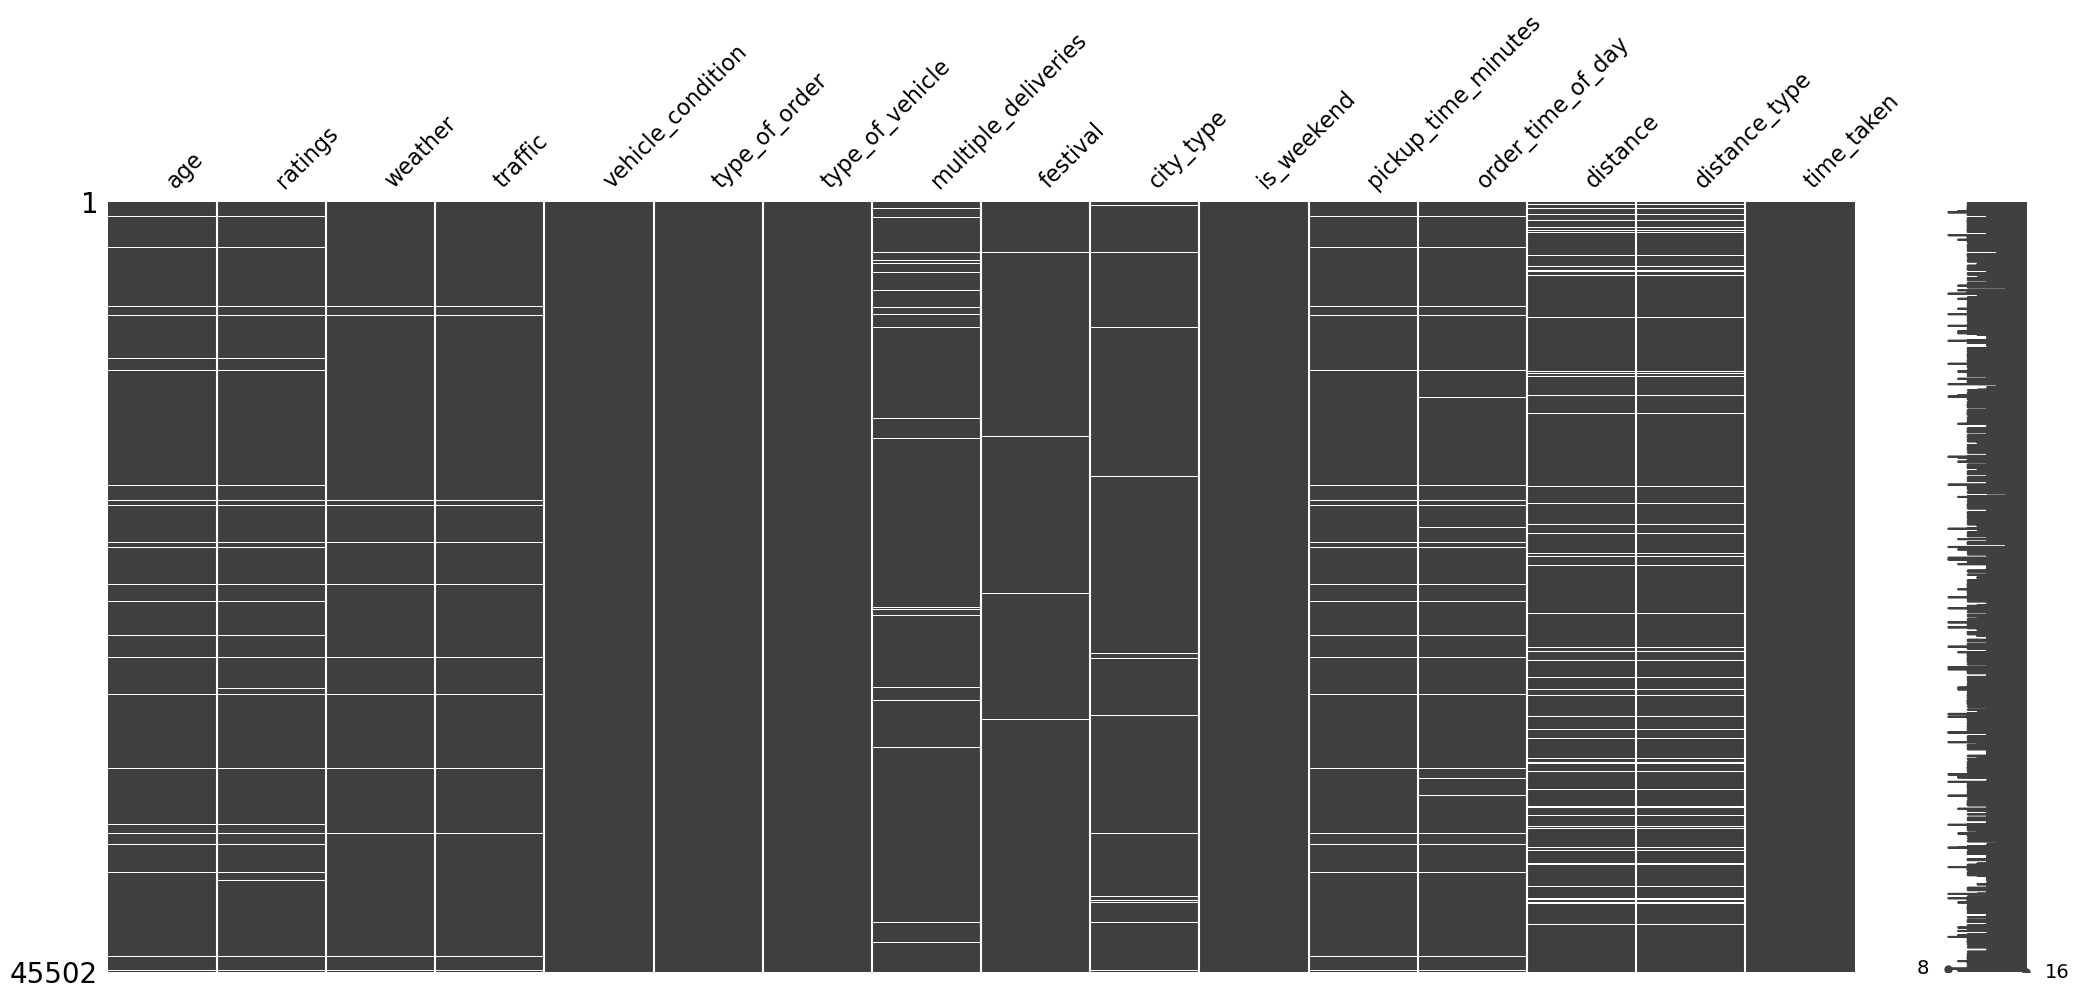

In [7]:
msno.matrix(data)
plt.show()

In [8]:
# missing colm list

missing_features = data.isna().any(axis=0).loc[lambda x: x].index
missing_features

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### drop missing values

In [9]:
temp_data = data.copy().dropna()

In [10]:
X = temp_data.drop('time_taken', axis = 1)
y = temp_data['time_taken']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30156, 15)
The shape of test data is (7539, 15)


In [13]:
# power transformer
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

### processing

In [14]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [15]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop = "first", handle_unknown = "ignore",
                                     sparse_output = False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories = [traffic_order,distance_type_order],
                                      encoded_missing_value = -999,
                                      handle_unknown = "use_encoded_value",
                                      unknown_value = -1), ordinal_cat_cols)
],remainder = "passthrough", n_jobs = -1, force_int_remainder_cols = False, verbose_feature_names_out = False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [16]:
# build the pipeline
processing_pipeline = Pipeline(steps=[
                                ("preprocess",preprocessor)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [17]:
X_train_transform = processing_pipeline.fit_transform(X_train)
X_test_transform = processing_pipeline.fit_transform(X_test)

In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
from sklearn.compose import TransformedTargetRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

In [21]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 1, 40),
        'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.8),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 100),
        'random_state': 42,
        'n_jobs': -1
    }

    xgb_regressor = LGBMRegressor(**params)
    model = TransformedTargetRegressor(regressor=xgb_regressor, transformer=pt)

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train_transform)
    y_pred_test = model.predict(X_test_transform)

    cv_score = cross_val_score(
        model,
        X_train_transform,  
        y_train,           
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mean_score = -cv_score.mean()
    return mean_score

In [ ]:
study = optuna.create_study(direction='minimize')

with mlflow.start_run(run_name='best_model'):
    study.optimize(objective, n_trials=50, n_jobs=-1, show_progress_bar=True)  # Fixed 'n_trail' to 'n_trials'

    mlflow.log_params(study.best_params)

    mlflow.log_metric('best_score', study.best_value)

    best_lgbm = LGBMRegressor(**study.best_params)

    best_lgbm.fit(X_train_transform, y_train_pt.values.ravel())

    y_pred_train = best_lgbm.predict(X_train_transform)
    y_pred_test = best_lgbm.predict(X_test_transform)  # Fixed: use X_test_transform for test prediction

    y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
    y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

    model = TransformedTargetRegressor(regressor=best_lgbm,
                                       transformer=pt)

    scores = cross_val_score(model,
                             X_train_transform,
                             y_train,
                             scoring='neg_mean_absolute_error', 
                             cv=5,
                             n_jobs=-1)

    mlflow.log_metric('training_error', mean_absolute_error(y_train, y_pred_train_org))
    mlflow.log_metric('test_error', mean_absolute_error(y_test, y_pred_test_org))
    mlflow.log_metric('training_r2', r2_score(y_train, y_pred_train_org))
    mlflow.log_metric('test_r2', r2_score(y_test, y_pred_test_org))
    mlflow.log_metric('cross_val', -scores.mean())

    mlflow.sklearn.log_model(best_lgbm, artifact_path='model')

In [ ]:
study.best_params

In [ ]:
study.best_value

In [ ]:
optuna.visualization.plot_param_importances(study)